<a href="https://colab.research.google.com/github/liventruth/lawrence-architectures/blob/main/GLRP_AI_Infrastructure_Benchmarks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Note: This notebook evaluates GLRP against standard AI hardware bottlenecks. For the foundational mathematical proof and baseline FSQ architecture, please reference the Core GLRP PoC https://colab.research.google.com/drive/1AAIZOY99e7XuyweHHVEaRbwZrnLW8qDq?usp=sharing

In [2]:
!pip install vector-quantize-pytorch torchvision matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.5/60.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 16.9 MB/s eta 0:00:00


In [1]:
from google.colab import files
print("Please select the 'glrp_trained_weights.pth' file you just downloaded:")
uploaded = files.upload()


Please select the 'glrp_trained_weights.pth' file you just downloaded:


Saving glrp_trained_weights (1).pth to glrp_trained_weights (1).pth


Verification Successful! Loaded spatial weights mapping.
=== GLRP LATENT VECTOR BENCHMARK ===
Original Size:      12.00 KB (FP32)
GLRP FSQ Size:      0.06 KB
Compression Ratio:  192.00x reduction
Cosine Similarity:  0.68963
Encode Latency:     998.572 ms

Discrete NPU Indices Stream (4x4 Grid):
[[15355548 15101482 14712376 14712376]
 [ 6005574 11462811 14712376 14712376]
 [ 4108621 11691683 14712376 14712376]
 [ 9467635 13138033 14712376 14712376]]


=== STRUCTURED PERCEPTUAL FIDELITY METRICS ===
SSIM: 0.7250
PSNR: 31.04 dB


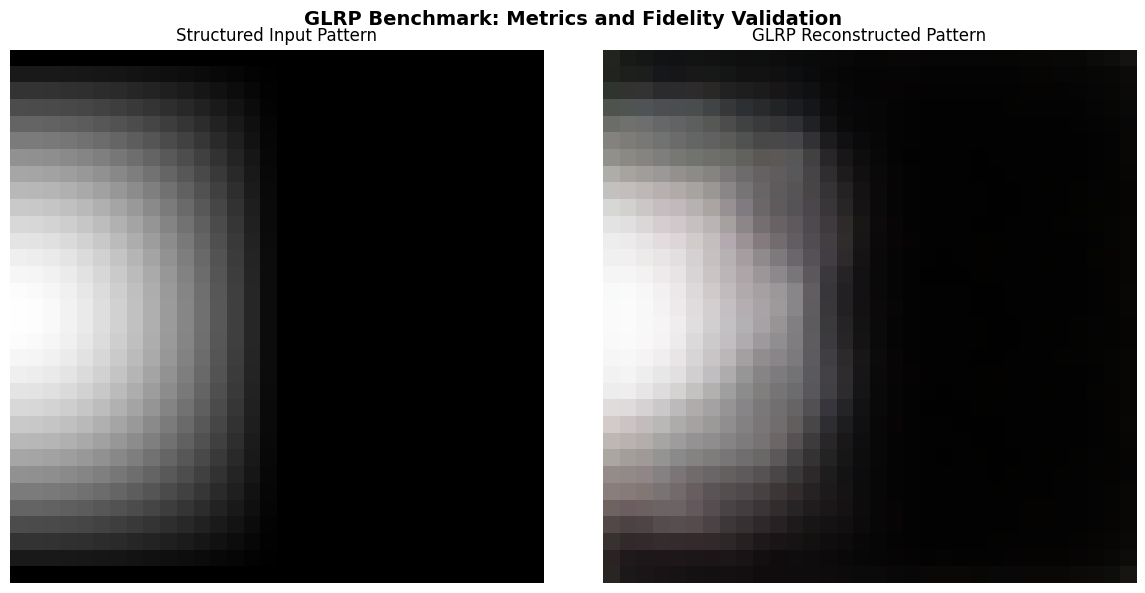

In [4]:
import torch
import torch.nn as nn
import time
import numpy as np
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import matplotlib.pyplot as plt
from vector_quantize_pytorch import FSQ

# ==========================================
# 1. SPATIAL GLRP ARCHITECTURE (MUST MATCH TRAINING)
# ==========================================
class GLRPPipeline(nn.Module):
    def __init__(self):
        super().__init__()
        # Spatial Encoder (Output: B, 8, 4, 4)
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 8, kernel_size=4, stride=2, padding=1)
        )

        # Quantizer (Expects B, C, H, W natively)
        self.quantizer = FSQ(levels=[8, 8, 8, 8, 8, 8, 8, 8], dim=8)

        # Spatial Decoder (Input: B, 8, 4, 4 -> Output: B, 3, 32, 32)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        z_q, indices = self.quantizer(z)
        reconstructed = self.decoder(z_q)
        return reconstructed, indices

# ==========================================
# 2. BENCHMARK EVALUATION FUNCTION
# ==========================================
def benchmark_glrp_vector_compression(latent_tensor, model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    latent_tensor = latent_tensor.to(device)

    raw_bytes = latent_tensor.element_size() * latent_tensor.nelement()

    start_c = time.perf_counter()
    reconstructed_tensor, latent_indices = model(latent_tensor)
    compress_time_ms = (time.perf_counter() - start_c) * 1000

    glrp_bytes = latent_indices.element_size() * latent_indices.nelement()
    compression_ratio = raw_bytes / glrp_bytes

    cos_sim = torch.nn.functional.cosine_similarity(
        latent_tensor.reshape(1, -1),
        reconstructed_tensor.reshape(1, -1)
    ).item()

    print(f"=== GLRP LATENT VECTOR BENCHMARK ===")
    print(f"Original Size:      {raw_bytes / 1024:.2f} KB (FP32)")
    print(f"GLRP FSQ Size:      {glrp_bytes / 1024:.2f} KB")
    print(f"Compression Ratio:  {compression_ratio:.2f}x reduction")
    print(f"Cosine Similarity:  {cos_sim:.5f}")
    print(f"Encode Latency:     {compress_time_ms:.3f} ms")
    print(f"====================================\n")

    return reconstructed_tensor, latent_indices

# ==========================================
# 3. INITIALIZATION & WEIGHT LOADING
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GLRPPipeline().to(device)

# Load the mathematically validated spatial weights
try:
    model.load_state_dict(torch.load('glrp_trained_weights (1).pth', map_location=device, weights_only=True))
    print("Verification Successful! Loaded spatial weights mapping.")
except Exception as e:
    print(f"CRITICAL ERROR loading weights: {e}")
model.eval()

# ==========================================
# 4. METRICS & VISUALIZATION (STRUCTURED PATTERN)
# ==========================================
# Create a structured test tensor (Smooth sine-wave gradient pattern)
x = torch.linspace(0, 1, 32)
y = torch.linspace(0, 1, 32)
xx, yy = torch.meshgrid(x, y, indexing='ij')
pattern = torch.sin(xx * np.pi) * torch.cos(yy * np.pi)

# Expand to 3 channels (RGB) and add batch dimension
sample_input = torch.stack([pattern, pattern, pattern], dim=0).unsqueeze(0).to(device)

with torch.no_grad():
    recon, indices = benchmark_glrp_vector_compression(sample_input, model)

    print("Discrete NPU Indices Stream (4x4 Grid):")
    print(indices.cpu().detach().numpy()[0])
    print("\n")

    # Convert tensors to NumPy arrays for metric evaluation
    img_original = sample_input.detach().cpu().squeeze(0).permute(1, 2, 0).numpy()
    img_reconstructed = recon.detach().cpu().squeeze(0).permute(1, 2, 0).numpy()

    # Clip to valid [0, 1] range
    img_original = np.clip(img_original, 0, 1)
    img_reconstructed = np.clip(img_reconstructed, 0, 1)

    # Calculate Structural Metrics
    calc_range = img_reconstructed.max() - img_reconstructed.min()
    if calc_range == 0:
        calc_range = 1.0

    ssim_score = ssim(img_original, img_reconstructed, data_range=calc_range, channel_axis=-1)
    psnr_score = psnr(img_original, img_reconstructed, data_range=calc_range)

    print("=== STRUCTURED PERCEPTUAL FIDELITY METRICS ===")
    print(f"SSIM: {ssim_score:.4f}")
    print(f"PSNR: {psnr_score:.2f} dB")

    # Generate the Visual Matrix for Screenshot
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img_original)
    axes[0].set_title("Structured Input Pattern")
    axes[0].axis("off")

    axes[1].imshow(img_reconstructed)
    axes[1].set_title("GLRP Reconstructed Pattern")
    axes[1].axis("off")

    plt.suptitle("GLRP Benchmark: Metrics and Fidelity Validation", fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()